/tmp/ipykernel_473573/3924910743.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_included[col].fillna('Unknown', inplace=True)
/tmp/ipykernel_473573/3924910743.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

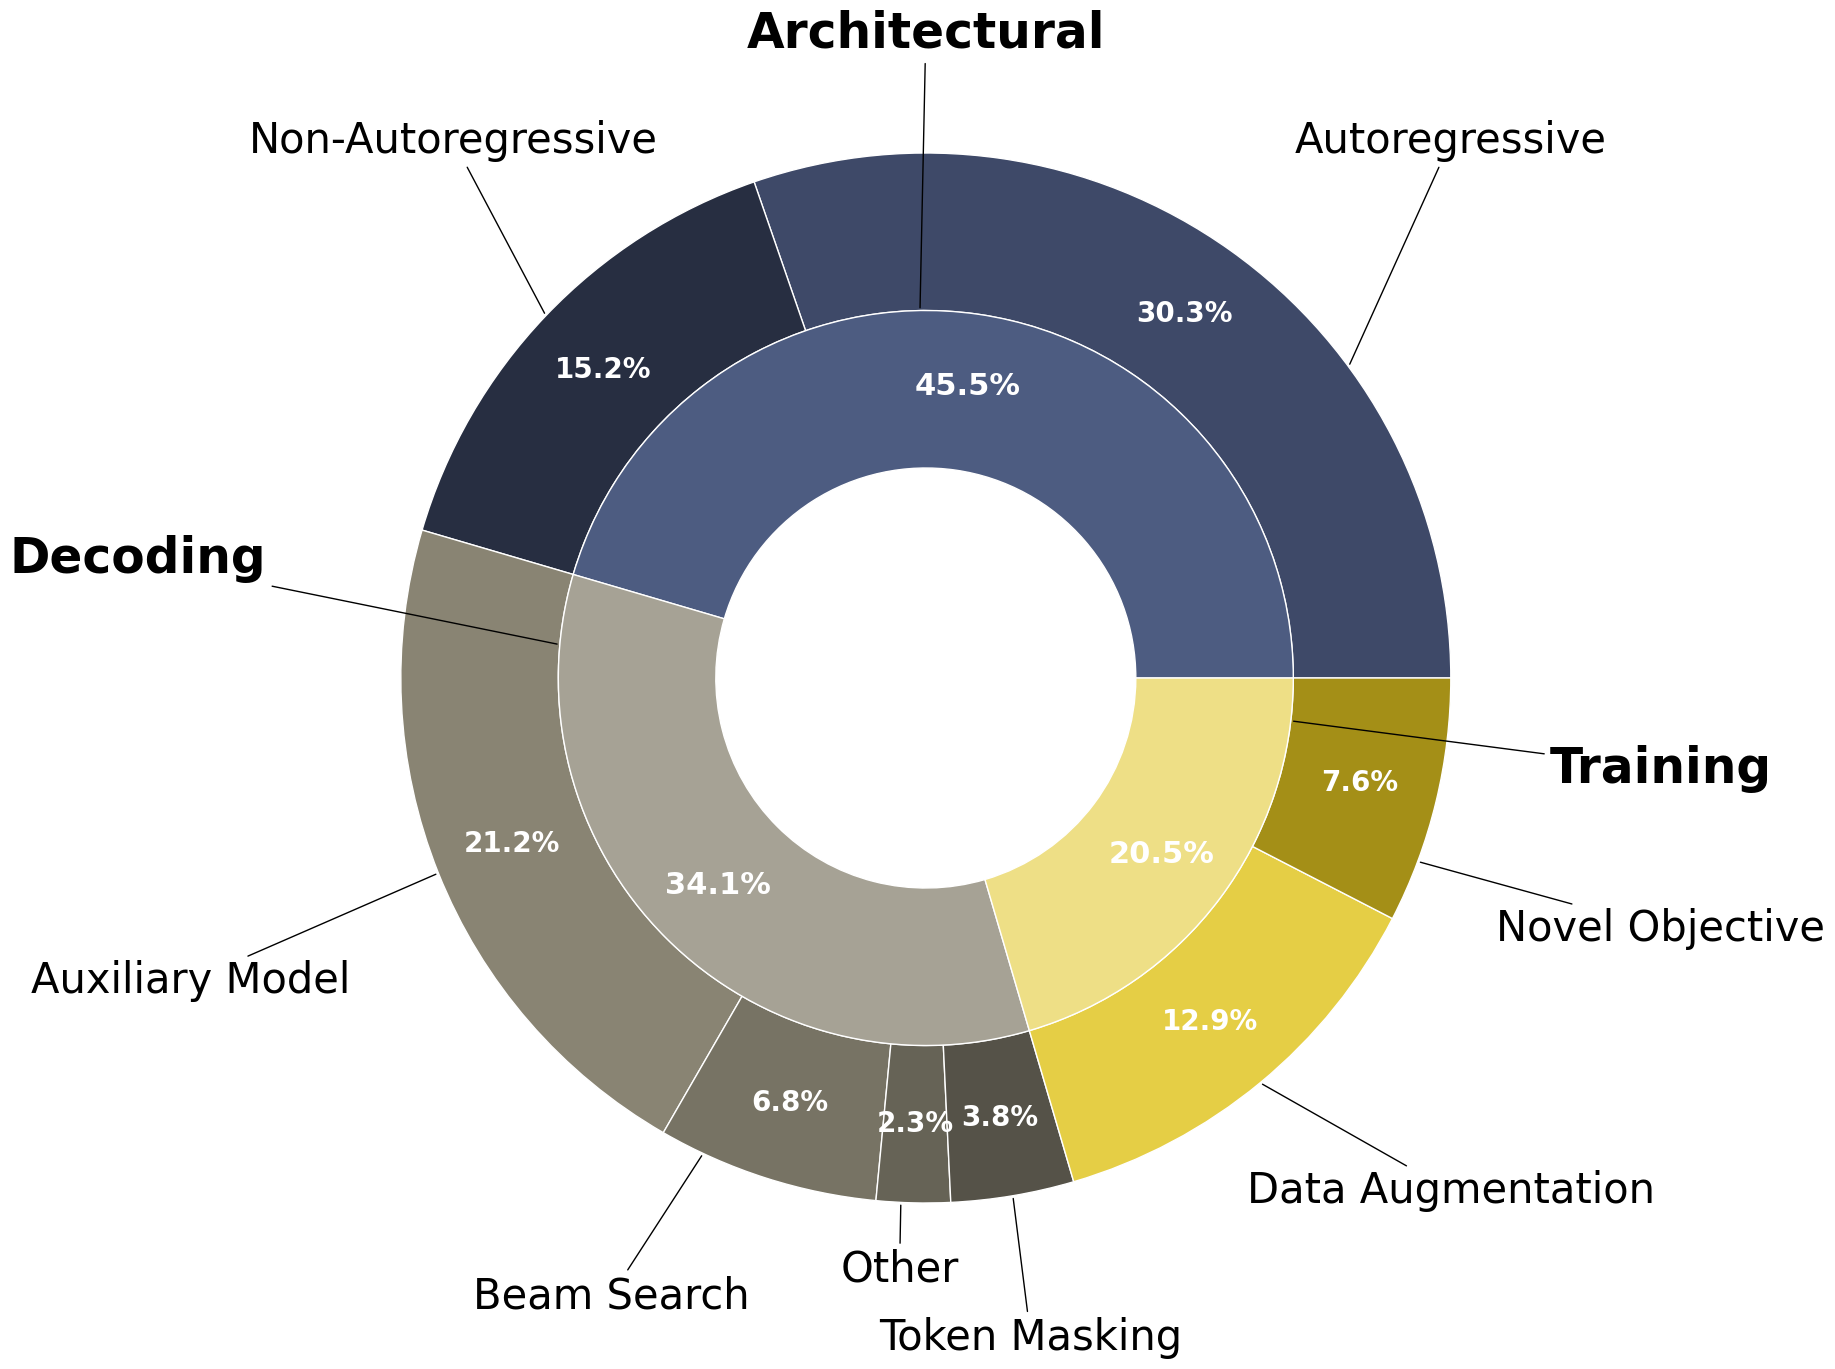

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set a nicer font
plt.rcParams['font.family'] = 'sans-serif'
# --- FONT STYLE SETTING ---
# You can change the font family for the labels here.
# For example, to use Times New Roman, you would change the list below to:
# plt.rcParams['font.sans-serif'] = ['Times New Roman', 'DejaVu Sans', 'Verdana']
plt.rcParams['font.sans-serif'] = ['Questrial', 'DejaVu Sans', 'Verdana'] 

# Load the dataset from the CSV file
df = pd.read_csv('final_taxonomy.csv')

# --- Data Preparation ---

# Filter for papers that are included in the review
df_included = df[df['included in review'] == 'Y'].copy()

# Clean up column names by removing leading/trailing whitespace
df_included.columns = df_included.columns.str.strip()

# Clean the 'General Method' and 'Specific Method' columns
# Strip whitespace, and replace empty strings or NaN values with 'Unknown'
for col in ['General Method', 'Specific Method']:
    df_included[col] = df_included[col].str.strip()
    df_included[col].fillna('Unknown', inplace=True)
    df_included.loc[df_included[col] == '', col] = 'Unknown'

# --- Data Aggregation ---

# Calculate the counts for each General Method
general_counts = df_included['General Method'].value_counts().sort_index()

# Calculate the counts for each Specific Method, grouped by General Method
specific_counts = df_included.groupby(['General Method', 'Specific Method']).size().sort_index()

# --- Plotting ---

# Prepare data for the pie chart (General Method on the inside, Specific on the outside)
outer_labels = specific_counts.index.get_level_values(1)
outer_sizes = specific_counts.values
inner_labels = general_counts.index
inner_sizes = general_counts.values

import colorsys

# Choose a qualitative colormap for the inner wedges
# inner_cmap = plt.get_cmap('Set2')
inner_cmap = plt.get_cmap('cividis')
num_colors = len(inner_labels)
offset = 0.24
inner_colors = inner_cmap(np.linspace(offset, offset + 1, num_colors, endpoint=False) % 1)

# Helper function to adjust lightness
def adjust_lightness(rgb, factor):
    """Adjust lightness by scaling the L channel in HLS space."""
    r, g, b = rgb[:3]
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    return colorsys.hls_to_rgb(h, l, s)

# Make the inner colors slightly lighter overall
inner_colors = [adjust_lightness(c, 1.2) for c in inner_colors]

# For each general method, create darker variations for its specific methods
outer_colors = []
num_specific_per_general = (
    df_included.groupby('General Method')['Specific Method']
    .nunique()
    .reindex(inner_labels)
)

for i, method in enumerate(inner_labels):
    base_color = inner_colors[i]
    n = num_specific_per_general[method]

    # Outer wedges get darker shades of the inner color
    factors = np.linspace(0.8, 0.5, n)  # smaller = darker
    shades = [adjust_lightness(base_color, f) for f in factors]

    outer_colors.extend(shades)

# Create the plot
fig, ax = plt.subplots(figsize=(20, 15))

# Plot the outer pie (Specific Method)
# Hiding percentages for small slices to prevent overlap
wedges_outer, _, autotexts_outer = ax.pie(outer_sizes, radius=1, labels=None, colors=outer_colors,
       wedgeprops=dict(width=0.3, edgecolor='w'), autopct=lambda p: f'{p:.1f}%' if p > 2 else '', pctdistance=0.85)

# Plot the inner pie (General Method)
wedges_inner, _, autotexts_inner = ax.pie(inner_sizes, radius=0.7, labels=None, colors=inner_colors,
       wedgeprops=dict(width=0.3, edgecolor='w'), autopct='%.1f%%', pctdistance=0.8)

plt.setp(autotexts_outer, size=20, weight="bold", color="white")
plt.setp(autotexts_inner, size=22, weight="bold", color="white")

# --- Aligning Labels with Arrows ---

# Common properties for annotations
bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=10)
arrow_props = dict(arrowstyle="-")

def add_annotations(
    wedges, labels, radius, text_radius, ax,
    font_size, font_weight=None,
    manual_positions=None, manual_angle_factors=None
):
    """
    Draws annotations for pie chart wedges.
    - manual_positions: dict[label] = (x, y)
    - manual_angle_factors: dict[label] = float divisor for angle calculation
    """
    items = []
    for i, p in enumerate(wedges):
        label = labels[i]
        factor = 2  # default midpoint
        if manual_angle_factors and label in manual_angle_factors:
            factor = manual_angle_factors[label]

        ang = (p.theta2 - p.theta1) / factor + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        items.append({'w': p, 'l': label, 'a': ang, 'x': x, 'y': y})

    left = sorted([i for i in items if i['x'] < 0], key=lambda i: i['y'])
    right = sorted([i for i in items if i['x'] >= 0], key=lambda i: i['y'], reverse=True)

    min_sep = 0.12

    if right:
        last_y = right[0]['y'] * text_radius
        right[0]['text_y'] = last_y
        for i in range(1, len(right)):
            y_pos = right[i]['y'] * text_radius
            if y_pos > last_y - min_sep:
                y_pos = last_y - min_sep
            right[i]['text_y'] = y_pos
            last_y = y_pos

    if left:
        last_y = left[0]['y'] * text_radius
        left[0]['text_y'] = last_y
        for i in range(1, len(left)):
            y_pos = left[i]['y'] * text_radius
            if y_pos < last_y + min_sep:
                y_pos = last_y + min_sep
            left[i]['text_y'] = y_pos
            last_y = y_pos

    for item in left + right:
        label = item['l']
        # Use manual override if provided
        if manual_positions and label in manual_positions:
            text_x, text_y = manual_positions[label]
            arrow_target = (radius * item['x'], radius * item['y'])
            ax.annotate(
                label,
                xy=arrow_target,
                xytext=(text_x, text_y),
                horizontalalignment='center',
                arrowprops=dict(arrowstyle="-"),# connectionstyle=f"arc3,rad=0.2"),
                fontsize=font_size,
                fontweight=font_weight,
                # bbox=dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=2),
            )
        else:
            connectionstyle = f"angle,angleA=0,angleB={item['a']}"
            ax.annotate(
                label,
                xy=(radius * item['x'], radius * item['y']),
                xytext=(-text_radius, item.get('text_y', item['y']*text_radius))
                if item['x'] < 0 else (text_radius, item.get('text_y', item['y']*text_radius)),
                horizontalalignment='right' if item['x'] < 0 else 'left',
                arrowprops=dict(arrowstyle="-"),#, connectionstyle=connectionstyle),
                fontsize=font_size,
                fontweight=font_weight,
                # bbox=dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=2),
            )

manual_positions_general = {
    'Architectural': ( 0, 1.2 ),
    'Decoding': ( -1.5, 0.2 ),
    'Training': ( 1.4, -0.2),
}

manual_positions_specific = {
    'Autoregressive': (1, 1),
    'Non-Autoregressive': (-0.9, 1),
    'Auxiliary Model': (-1.4, -0.6),
    'Beam Search': (-0.6, -1.2),
    'Other': (-0.05, -1.15),
    'Token Masking': (0.2, -1.28),
    'Data Augmentation': (1, -1),
    'Novel Objective': (1.4, -0.5),
}            
            
manual_angle_factors_general = {
    'Architectural': 1.8,
    'Decoding': 11,
    'Training': 1.1,
}

manual_angle_factors_specific = {
    'Beam Search': 5.0,
    'Novel Objective': 4,
    'Other': 3,
    'Autoregressive': 3
}
 
    
add_annotations(
    wedges_inner, inner_labels, 0.7, 1.3, ax, 35,
    font_weight='bold',
    manual_positions=manual_positions_general,
    manual_angle_factors=manual_angle_factors_general
)

add_annotations(
    wedges_outer, outer_labels, 1, 1.3, ax, 30,
    manual_positions=manual_positions_specific,
    manual_angle_factors=manual_angle_factors_specific
)


ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
# fig.tight_layout()
# plt.show()
plt.savefig("pie.png", dpi=300)